# Importacion de librerias

### Librerias manejo de datos

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Librerias Machine Learning

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import statsmodels.api as sm
from scipy import stats 

### Configuracion para que lo graficos se venan dentro del notebook

In [8]:
%matplotlib inline
sns.set_style('whitegrid')

# importacion de la data

In [9]:
df = pd.read_csv("../data/raw/train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [10]:
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

(1460, 81)

In [11]:
df["GrLivArea"].info()

<class 'pandas.Series'>
RangeIndex: 1460 entries, 0 to 1459
Series name: GrLivArea
Non-Null Count  Dtype
--------------  -----
1460 non-null   int64
dtypes: int64(1)
memory usage: 11.5 KB


# Division de los datos (Train/Test Split)

### Variable objetivo $y$ y Variable predictora $X$

In [12]:
y=df["SalePrice"]
#[[]] porque debe ser un DataFrame
X=df[["GrLivArea"]]

### division de los datos

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

In [14]:
print(f"Entrenamiento: {X_train.shape[0]} casas")
print(f"Prueba: {X_test.shape[0]} casas")

# Debe dar True si todo está bien sincronizado
print(len(X_train) == len(y_train))

Entrenamiento: 1168 casas
Prueba: 292 casas
True


# EDA

In [15]:
desc_df = pd.concat([X_train, y_train], axis=1)

### Estadísticas descriptivas

In [16]:
print(desc_df.describe())

         GrLivArea      SalePrice
count  1168.000000    1168.000000
mean   1527.401541  181441.541952
std     524.432686   77263.583862
min     334.000000   34900.000000
25%    1145.750000  130000.000000
50%    1473.000000  165000.000000
75%    1792.000000  214925.000000
max    5642.000000  745000.000000


### Identificar valores nulos

In [17]:
desc_df.isnull().sum()

GrLivArea    0
SalePrice    0
dtype: int64

### Distribuciones y Outliers

Esta función calcula la media ($\mu$) y la desviación estándar ($\sigma$) que mejor describen a tus datos.

In [20]:
mu, sigma = stats.norm.fit(y_train)
print(f"Media (mu): {mu:.2f}")
print(f"Desviación Estándar (sigma): {sigma:.2f}")

Media (mu): 181441.54
Desviación Estándar (sigma): 77230.50


### Normalidad

#### Grafico Normalidad

<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:30: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:30: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_948/3649695641.py:21: SyntaxWarning: invalid escape sequence '\m'
  plt.axvline(mu, color='black', linestyle='--', lw=2, label=f'Promedio ($\mu$): {mu:,.0f}')
/tmp/ipykernel_948/3649695641.py:25: SyntaxWarning: invalid escape sequence '\s'
  plt.axvline(mu + sigma, color='darkred', linestyle=':', lw=1.5, label=f'Desv. Est. ($\sigma$): {sigma:,.0f}')
/tmp/ipykernel_948/3649695641.py:30: SyntaxWarning: invalid escape sequence '\s'
  color='red', alpha=0.1, label='Área de Confianza (1 $\sigma$)')


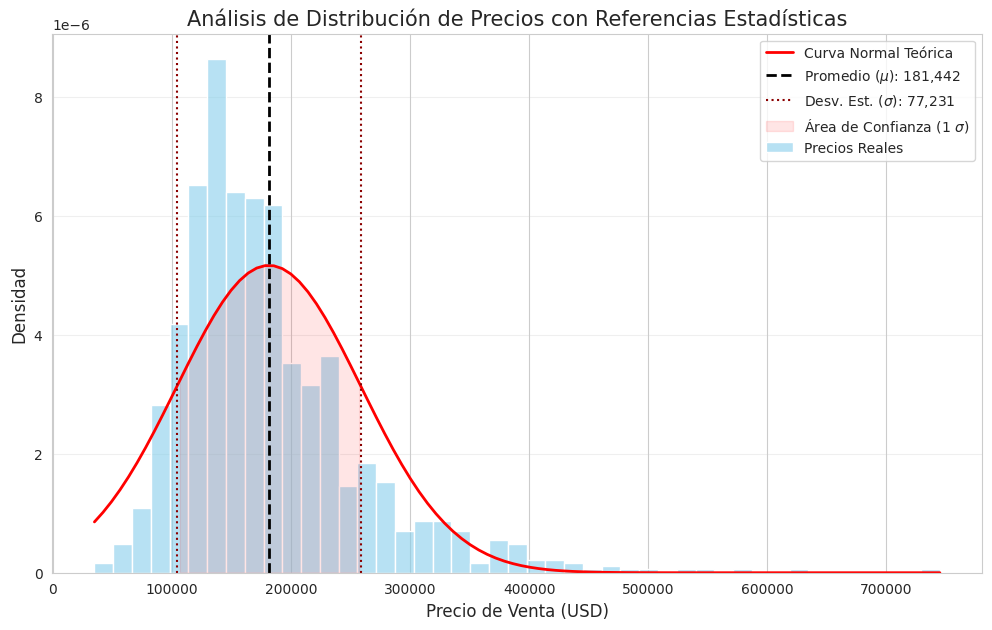

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

# 1. Calcular los parámetros de la normal
(mu, sigma) = stats.norm.fit(y_train)

# 2. Crear la figura
plt.figure(figsize=(12, 7))

# 3. Histograma de densidad
sns.histplot(y_train, kde=False, stat="density", color='skyblue', alpha=0.6, label='Precios Reales')

# 4. Curva de la Normal teórica
x_range = np.linspace(y_train.min(), y_train.max(), 100)
pdf = stats.norm.pdf(x_range, mu, sigma)
plt.plot(x_range, pdf, color='red', lw=2, label=f'Curva Normal Teórica')

# 5. Línea para el Promedio (mu)
plt.axvline(mu, color='black', linestyle='--', lw=2, label=f'Promedio ($\mu$): {mu:,.0f}')

# 6. Líneas para la Desviación Estándar (mu + sigma y mu - sigma)
# Usamos un color distinto y una línea más fina para diferenciarla del promedio
plt.axvline(mu + sigma, color='darkred', linestyle=':', lw=1.5, label=f'Desv. Est. ($\sigma$): {sigma:,.0f}')
plt.axvline(mu - sigma, color='darkred', linestyle=':', lw=1.5)

# Sombrear opcional para resaltar el área de una desviación estándar (muy profesional)
plt.fill_between(x_range, pdf, where=(x_range >= mu - sigma) & (x_range <= mu + sigma), 
                 color='red', alpha=0.1, label='Área de Confianza (1 $\sigma$)')

# Personalizar final
plt.title('Análisis de Distribución de Precios con Referencias Estadísticas', fontsize=15)
plt.xlabel('Precio de Venta (USD)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.legend(loc='upper right', fontsize=10)
plt.grid(axis='y', alpha=0.3) # Una grilla ligera ayuda a la lectura

plt.show()

#### Prueba estadística supuesto de Normalidad

Pruebas de hipótesis estadísticas para evaluar el valor $p$ con el fin de decidir si los datos siguen una distribución normal o no.

Pruebas  **Shapiro-Wilk** y la de **D'Agostino's $K^2$**.

En estadística, para ambas pruebas se define:

* **Hipótesis Nula ($H_0$):** Los datos siguen una distribución normal.
* **Hipótesis Alternativa ($H_1$):** Los datos **no** siguen una distribución normal.

Si el **valor $p \le 0.05$**, se rechaza la normalidad.

In [23]:
# 1. Prueba de Shapiro-Wilk 
# (Muy potente, pero sensible en muestras grandes como Ames)
shapiro_stat, shapiro_p = stats.shapiro(y_train)

# 2. Prueba de D'Agostino's K^2 
# (Mide asimetría y curtosis combinadas)
k2_stat, k2_p = stats.normaltest(y_train)

print("--- Resultados de las Pruebas de Normalidad ---")
print(f"Shapiro-Wilk: p-value = {shapiro_p:.4f}")
print(f"D'Agostino K^2: p-value = {k2_p:.4f}")

# Interpretación automática
if k2_p > 0.05:
    print("\nConclusión: No se puede rechazar la normalidad (parece normal).")
else:
    print("\nConclusión: Se rechaza la normalidad (los datos NO son normales).")

--- Resultados de las Pruebas de Normalidad ---
Shapiro-Wilk: p-value = 0.0000
D'Agostino K^2: p-value = 0.0000

Conclusión: Se rechaza la normalidad (los datos NO son normales).


### Q-Q Plot

un **Gráfico Cuantil-Cuantil (Q-Q Plot)** compara los cuantiles de tus datos contra los cuantiles de una distribución normal teórica.


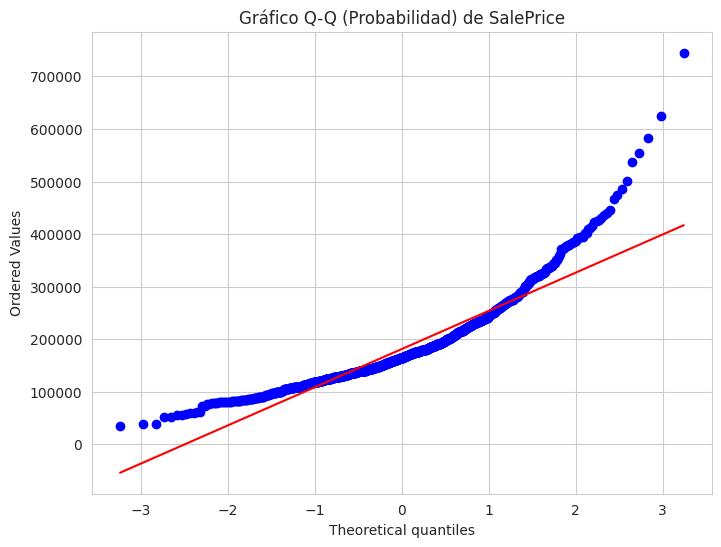

In [24]:
plt.figure(figsize=(8, 6))
stats.probplot(y_train, plot=plt)
plt.title('Gráfico Q-Q (Probabilidad) de SalePrice')
plt.show()

#### ¿Cómo interpretar el Q-Q Plot?

* **Línea Roja Diagonal:** Representa una distribución normal perfecta.
* **Puntos Azules:** Son tus datos reales.
* **Diagnóstico:** Si los puntos azules se curvan y se alejan de la línea roja en los extremos (las "colas"), confirma que tienes **outliers** o un **sesgo** significativo, lo cual invalida el supuesto de normalidad para la Regresión Lineal.

---

### Resumen del Diagnóstico

| Prueba | Valor Esperado (Normalidad) | Resultado en Ames Housing |
| --- | --- | --- |
| **Shapiro-Wilk ($p$)** | $> 0.05$ | Generalmente muy cercano a $0$ |
| **D'Agostino ($p$)** | $> 0.05$ | Generalmente muy cercano a $0$ |
| **Q-Q Plot** | Puntos sobre la diagonal | Puntos curvados en los extremos |

Debido al sesgo de los precios en el dataset de Ames, verás que las pruebas estadísticas **rechazan la normalidad de forma contundente** ($p < 0.05$). Esto es normal en datos financieros y de vivienda.

¿Te gustaría que apliquemos una **Transformación Logarítmica** a los precios para ver cómo las pruebas estadísticas y el Q-Q Plot cambian mágicamente hacia una normalidad casi perfecta?

* **4.1. Estadísticas descriptivas:** (Lo que llamabas "obtener métricas"). Ver promedios, mínimos y máximos con `df.describe()`.
* **4.2. Identificar valores nulos:** Ver cuántos faltan en cada columna.
* **4.3. Distribuciones y Outliers:** Aquí entran tus **Boxplots** y los Histogramas. Te sirven para ver si hay casas con precios absurdamente altos o tamaños imposibles.
* **4.4. Análisis de correlación:** Usar gráficos de dispersión (Scatter plots) y mapas de calor (Heatmaps) para ver qué variable se relaciona mejor con el Precio de Venta.

# Preprocesamiento y Feature Engineering 

* **5.1. Limpieza de valores nulos:** Decidir si borras las filas, o si rellenas los vacíos con el promedio o la mediana.
* **5.2. Transformaciones adicionales:** (Para tu primer modelo simple con una sola variable, esta parte será casi nula, pero es bueno dejar el espacio).

# Entrenamiento del modelo

# Metricas de evaluacion 

* **MAE:** Error Absoluto Medio.
* **MSE / RMSE:** Error Cuadrático Medio.
* **$R^2$:** Coeficiente de determinación (qué tan bien se ajusta la línea a los puntos).